In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import numpy as np

In [2]:
data = pd.read_csv('../data/runtime_data.csv',index_col=0)

In [3]:
# only keep NVL and drop redunant pcie
data = data[data.gpu!='h100_pcie:4']
data['Architecture'] = data['Architecture'].apply(lambda s: s.replace(" NVL",""))
data['N GPUs'] = data['gpu'].apply(lambda x: int(x.split(":")[1]) if x !='RTX 6000' else 1)

In [4]:
data

,gpu,Architecture,job_id,avg_runtime_s,median_runtime_s,max_runtime_s,N GPUs
5,nvidia_h200_nvl:8,NVIDIA H200,4695996,506.770000,499.0,545.0,8
3,h100_nvl:8,NVIDIA H100,3591010,602.280000,487.0,1136.0,8
6,RTX 6000,NVIDIA RTX 6000,dell,626.444444,626.0,632.0,1
0,a100:4,NVIDIA A100,3590290,863.900000,864.0,872.0,4
2,l40s:4,NVIDIA L40S,3590942,1202.570000,1203.0,1232.0,4
1,a40:4,NVIDIA A40,3590659,1721.850000,1751.0,1781.0,4


In [5]:
# get AWS Cloud costs from https://getdeploying.com/gpus
costs = {
    'NVIDIA H200': 7.91,
    'NVIDIA H100': 6.88,
    'NVIDIA RTX 6000': 4.32,
    'NVIDIA A100': 2.74,
    'NVIDIA L40S': 1.86,
    'NVIDIA A40': 1.50
}

In [6]:
data['hourly_cost'] = data['Architecture'].apply(costs.get)
data['time_per_seed'] = data['avg_runtime_s'].apply(lambda x: x/10)
data['cost_per_seed'] = data.apply(lambda row: 
                                   (row['time_per_seed']/3600)* row['hourly_cost'] ,axis=1)

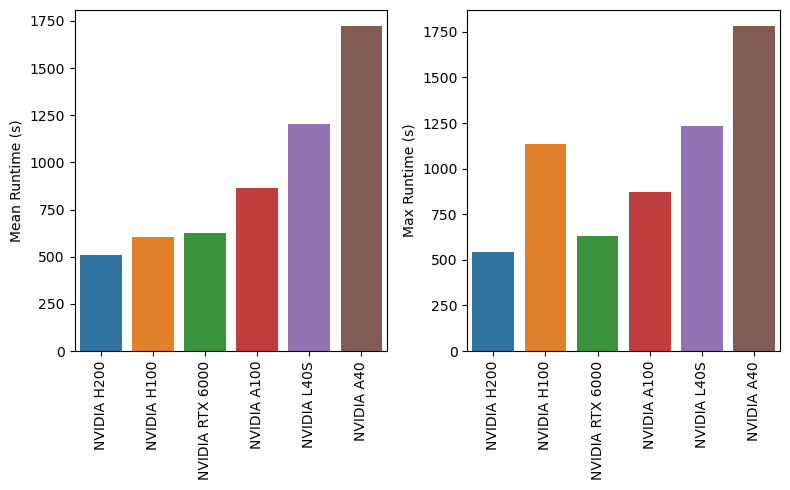

In [7]:
fig, axes = plt.subplots(ncols=2, figsize=(8, 5))

sns.barplot(
    data=data,
    x='Architecture',
    hue='Architecture',
    y='avg_runtime_s',
    ax=axes[0]
)

axes[0].tick_params(axis='x', rotation=90)
axes[0].set_xlabel('')
axes[0].set_ylabel('Mean Runtime (s)')


sns.barplot(
    data=data,
    x='Architecture',
    hue='Architecture',
    y='max_runtime_s',
    ax=axes[1]
)

axes[1].tick_params(axis='x', rotation=90)
axes[1].set_xlabel('')
axes[1].set_ylabel('Max Runtime (s)')

fig.tight_layout()


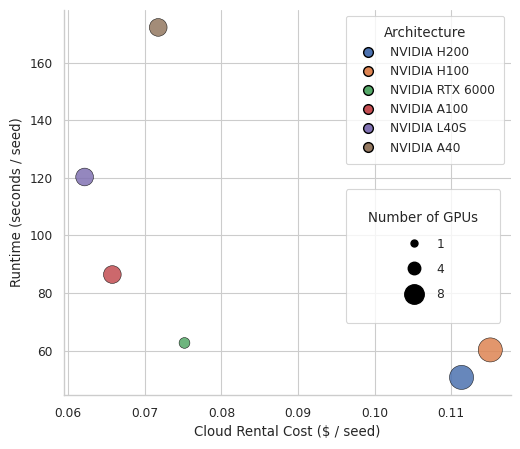

In [8]:
from matplotlib.lines import Line2D

# Theme
sns.set_theme(style="whitegrid", context="paper")

fig, ax = plt.subplots(figsize=(7.5, 5))

# Plot (NO legend)
sns.scatterplot(
    data=data,
    x='cost_per_seed',
    y='time_per_seed',
    hue='Architecture',
    size='N GPUs',
    sizes=(60, 300),
    alpha=0.85,
    edgecolor='black',
    linewidth=0.4,
    legend=False,
    ax=ax
)

# Labels
ax.set_xlabel('Cloud Rental Cost ($ / seed)')
ax.set_ylabel('Runtime (seconds / seed)')
sns.despine(ax=ax)

# ---------------------------
# Build legends manually
# ---------------------------

# Unique values
architectures = list(data['Architecture'].unique())
gpu_sizes = sorted(data['N GPUs'].unique())

# Colors (match seaborn default)
palette = sns.color_palette(n_colors=len(architectures))

# --- Architecture legend ---
arch_handles = [
    Line2D([0], [0],
           marker='o',
           color='w',
           markerfacecolor=palette[i],
           markeredgecolor='black',
           markersize=7,
           label=arch)
    for i, arch in enumerate(architectures)
]

leg1 = ax.legend(
    handles=arch_handles,
    title="Architecture",
    loc='upper right',
    frameon=True,
    borderpad=0.8
)

# --- Size legend ---
size_min, size_max = 60, 300
vmin, vmax = min(gpu_sizes), max(gpu_sizes)

def scale(s):
    if vmax == vmin:
        return size_min
    return size_min + (s - vmin) / (vmax - vmin) * (size_max - size_min)

vmin, vmax = 1, 8
rep_sizes = np.linspace(vmin, vmax, 3)

legend_marker_sizes = [5, 9, 14]  

size_handles = [
    Line2D([0], [0],
           marker='o',
           color='black',
           linestyle='',
           markersize=ms,
           label=f"{int(s)}")
    for s, ms in zip(rep_sizes, legend_marker_sizes)
]

leg2 = ax.legend(
    handles=size_handles,
    title="Number of GPUs",
    loc='upper right',
    bbox_to_anchor=(.99, 0.55),
    frameon=True,
    borderpad=1.8,
    labelspacing=1  # extra vertical spacing helps too
)
# Keep both legends
ax.add_artist(leg1)

# ---------------------------
# Layout fix (KEY LINE)
# ---------------------------
plt.subplots_adjust(right=0.72)

plt.savefig('cost_scaling.png')
plt.savefig('cost_scaling.svg')

In [9]:
vdjdb_size = 2*6016

In [10]:
data

,gpu,Architecture,job_id,avg_runtime_s,median_runtime_s,max_runtime_s,N GPUs,hourly_cost,time_per_seed,cost_per_seed
5,nvidia_h200_nvl:8,NVIDIA H200,4695996,506.770000,499.0,545.0,8,7.91,50.677000,0.111349
3,h100_nvl:8,NVIDIA H100,3591010,602.280000,487.0,1136.0,8,6.88,60.228000,0.115102
6,RTX 6000,NVIDIA RTX 6000,dell,626.444444,626.0,632.0,1,4.32,62.644444,0.075173
0,a100:4,NVIDIA A100,3590290,863.900000,864.0,872.0,4,2.74,86.390000,0.065752
2,l40s:4,NVIDIA L40S,3590942,1202.570000,1203.0,1232.0,4,1.86,120.257000,0.062133
1,a40:4,NVIDIA A40,3590659,1721.850000,1751.0,1781.0,4,1.50,172.185000,0.071744


In [11]:
_performance = pd.read_csv('../data/performance_by_seeds.csv',index_col=0)
indexes = [5,10,15,20,25,30,35,40,45,50]
performance = _performance[_performance['n_structures'].isin(indexes)].reset_index()['auc_mean_mean']
performance

0    0.776668
1    0.786605
2    0.791765
3    0.794958
4    0.796191
5    0.796275
6    0.797391
7    0.797824
8    0.798411
9    0.798664
Name: auc_mean_mean, dtype: float64

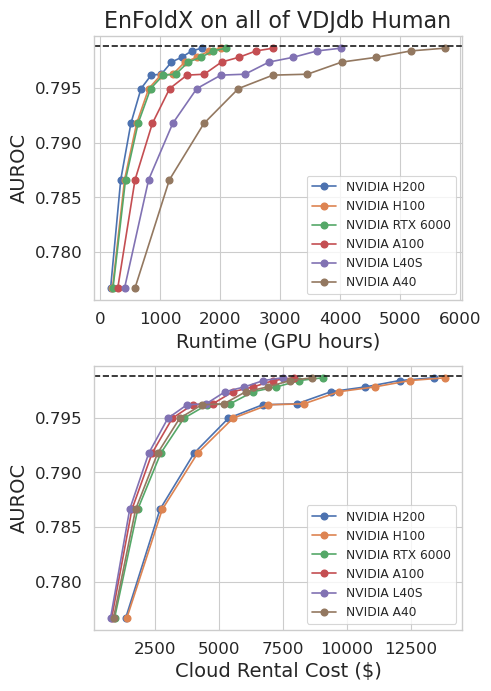

In [12]:
fig, axes= plt.subplots(nrows=2,figsize=(5,7),sharey=True)

for i, row in data.iterrows():
    time = row['time_per_seed']
    Y = [(time/3600)*_x*vdjdb_size for _x in range(1,11)]
    cost = row['cost_per_seed']
    Y2 = [(cost)*_x*vdjdb_size for _x in range(1,11)]
    # plt.plot(Y,X,'-o')
    axes[0].plot(Y,performance,'-o',label=row['Architecture'])
    axes[1].plot(Y2,performance,'-o',label=row['Architecture'])
axes[0].legend()
axes[0].axhline(performance.max()+.0002,linestyle='--',color='k')
axes[0].set_xlabel('Runtime (GPU hours)',fontsize=14)
axes[0].set_ylabel('AUROC',fontsize=14)
axes[0].tick_params(labelsize=12)

axes[0].set_title('EnFoldX on all of VDJdb Human',fontsize=16)

axes[1].legend()
axes[1].axhline(performance.max()+.0002,linestyle='--',color='k')
axes[1].set_xlabel('Cloud Rental Cost ($)',fontsize=14)
axes[1].tick_params( labelsize=12)
axes[1].set_ylabel('AUROC',fontsize=14)
fig.tight_layout()

fig.savefig('accuracy_profiling_vdjdb.png',bbox_inches='tight')
fig.savefig('accuracy_profiling_vdjdb.svg',bbox_inches='tight')

In [13]:
7.91*vdjdb_size*10

951731.2